In [26]:
#Importing main module
from cosmicfishpie.fishermatrix.cosmicfish import FisherMatrix
import numpy as np
from cosmicfishpie.utilities.utils import printing as upr

# Choose input parameters

In [2]:
#Define the observables you are interested in
observables = [['GCsp'],['WL']]

runRootName = "LCDM_5SYMB_HMc"
#Input options for CosmicFish (global options)
options = {'accuracy': 1,
           #'outroot': 'LCDM_camb_int-full-HMc2020',
           'results_dir': 'results/',
           'derivatives': '3PT',
           'nonlinear': True,
           'feedback': 2,
           'survey_name': 'Euclid',
           'specs_dir' : '../survey_specifications/',
           'survey_name_photo': 'Euclid-Photometric-'+'ISTF-Pessimistic',
           #'survey_name_spectro': 'Euclid-Spectroscopic-'+'ISTF-Pessimistic',
           'cosmo_model' : 'LCDM',
           'code': 'symbolic',
           'camb_config_yaml':'../boltzmann_yaml_files/camb/default.yaml'}

#Internally Cosmicfish converts these Parameters to the coresponding parameters in CAMB or CLASS 
fiducial = {
            "Omegam":0.3186,
            #'omch2':0.121259,
            #"ombh2":0.0227,
            "Omegab": 0.0491989,
            #"w0":-1.0,
            #"wa":0.,
            "h":0.6737,
            "ns":0.966,
            #"logAs":3.04,
            "sigma8" : 0.82,
            "mnu":0.0,
            #"Neff":3.043
            }

#Intrinsic alignment modeling.
IApars = {'IA_model': 'eNLA',
          'AIA': 0.16,
          'betaIA': 0.0,
          'etaIA': 1.66}
#Parameters to be varied and analyzed and their percentage variation for numerical derivatives
# IA params and photometric galaxy bias are added automatically to these parameters
freepars = {
            #'omch2': 0.01,
            #'ombh2': 0.01,
            #'logAs' : 0.01,
            #'w0': 0.01,
            #'wa': 0.01,
            'Omegab':0.01,
            'h': 0.01,
            'ns': 0.01,
            'sigma8': 0.01,
            'Omegam':0.01,
            }

In [3]:
specsdics = [
    {'name': 'lmax3000',
     'lmax_WL' :  3000
     },
    {'name': 'lmax750',
     'lmax_WL' :  750
     },
    {'name': 'lmax1500',
     'lmax_WL' :  1500
     },
    {'name': 'lmax5000',
     'lmax_WL' :  5000
     }
]

In [4]:
runFishers = True
runCosmo = True
upr.debug = False

## Run Fishers

In [5]:
FishersList = []
cosmoFM = dict()
for obse in observables:
    for specd in specsdics:
        options['outroot'] = runRootName
        options['outroot'] = options['outroot']+"-"+specd.get('name')
        print("-->running: ", options['outroot'])
        print("Dic to add: ")
        print(specd)
        if runCosmo:
            cosmoFM[options['outroot']] = FisherMatrix(fiducialpars=fiducial, 
                                freepars=freepars, 
                                options=options,
                                IApars=IApars,
                                observables=obse,
                                cosmoModel=options['cosmo_model'],
                                surveyName=options['survey_name'],
                                specifications=specd
                                )
        if runFishers:
            FishersList.append(cosmoFM[options['outroot']].compute())

-->running:  LCDM_5SYMB_HMc-lmax3000
Dic to add: 
{'name': 'lmax3000', 'lmax_WL': 3000}
**************************************************************
   _____               _     _____     __  
  / ___/__  ___ __ _  (_)___/ __(_)__ / /  
 / /__/ _ \(_-</  ' \/ / __/ _// (_-</ _ \ 
 \___/\___/___/_/_/_/_/\__/_/ /_/___/_//_/ 

**************************************************************
 This is the new Python version of the CosmicFish code.
**************************************************************
Custom fiducial parameters loaded

  -> Computing cosmology at the fiducial point

  ---> Cosmological functions obtained in:   0.10 s

----------RECAP OF SELECTED OPTIONS--------

Settings:
   accuracy: 1
   results_dir: results/
   derivatives: 3PT
   nonlinear: True
   feedback: 2
   survey_name: Euclid
   specs_dir: ../survey_specifications/
   survey_name_photo: Euclid-Photometric-ISTF-Pessimistic
   cosmo_model: LCDM
   code: symbolic
   camb_config_yaml: ../boltzmann_yaml_files/

In [6]:
#cfg.fiducialcosmo.cambcosmopars

# Plot Fishers

In [2]:
import glob
from cosmicfishpie.analysis import fisher_matrix as fm
from cosmicfishpie.analysis import fisher_operations as fo
from cosmicfishpie.analysis import fisher_plotting as fpp
from cosmicfishpie.analysis import colors
import numpy as np

## Fisher Matrices ISTF pars

### Loading Fisher Matrices from files

In [3]:
file_list = glob.glob('./results/CosmicFish_v1.0*LCDM*fishermatrix.txt')
file_list.sort()
for fi, ff in enumerate(file_list):
    print(f"ii: {fi}, file name: {ff}")

ii: 0, file name: ./results/CosmicFish_v1.0_LCDM+Mnu+Neff_internal_class-Euclid-Optimistic_3PT_GCsp_fishermatrix.txt
ii: 1, file name: ./results/CosmicFish_v1.0_LCDM+Mnu+Neff_internal_class-Euclid-Superpessimistic_3PT_GCsp_fishermatrix.txt
ii: 2, file name: ./results/CosmicFish_v1.0_LCDM_5SYMB_HMc-lmax1500_WL_fishermatrix.txt
ii: 3, file name: ./results/CosmicFish_v1.0_LCDM_5SYMB_HMc-lmax3000_WL_fishermatrix.txt
ii: 4, file name: ./results/CosmicFish_v1.0_LCDM_5SYMB_HMc-lmax5000_WL_fishermatrix.txt
ii: 5, file name: ./results/CosmicFish_v1.0_LCDM_5SYMB_HMc-lmax750_WL_fishermatrix.txt
ii: 6, file name: ./results/CosmicFish_v1.0_LCDM_5pcamb_HMc-lmax1500_WL_fishermatrix.txt
ii: 7, file name: ./results/CosmicFish_v1.0_LCDM_5pcamb_HMc-lmax3000_WL_fishermatrix.txt
ii: 8, file name: ./results/CosmicFish_v1.0_LCDM_5pcamb_HMc-lmax5000_WL_fishermatrix.txt
ii: 9, file name: ./results/CosmicFish_v1.0_LCDM_5pcamb_HMc-lmax750_WL_fishermatrix.txt
ii: 10, file name: ./results/CosmicFish_v1.0_LCDM_camb

In [4]:
file_list_filter = [file_list[ii] for ii in [2,6]]
print(file_list_filter)
fisher_list = [fm.fisher_matrix(file_name=ff) for ff in file_list_filter]

['./results/CosmicFish_v1.0_LCDM_5SYMB_HMc-lmax1500_WL_fishermatrix.txt', './results/CosmicFish_v1.0_LCDM_5pcamb_HMc-lmax1500_WL_fishermatrix.txt']


In [7]:
fiducial = {
            "Omegam":0.3186,
            #'omch2':0.121259,
            "ombh2":0.0227,
            "Omegab": 0.0491989,
            #"w0":-1.0,
            #"wa":0.,
            "h":0.6737,
            "ns":0.966,
            #"logAs":3.04,
            "sigma8" : 0.82,
            "mnu":0.0,
            #"Neff":3.043
            }

In [8]:
Fishes = fisher_list
#plotFishnames = [fish.name for fish in fisher_list]
plotFishnames = [
    'WL LCDM_5par symbolic elmx = 1500',
    'WL LCDM_5par camb elmx = 1500',
    ]
plotFishnames

['WL LCDM_5par symbolic elmx = 1500', 'WL LCDM_5par camb elmx = 1500']

In [19]:
print(Fishes[0].get_param_names())
print(Fishes[0].get_confidence_bounds())
print(Fishes[0].get_param_fiducial())
print(Fishes[1].get_param_names())
print(Fishes[1].get_confidence_bounds())
print(Fishes[1].get_param_fiducial())

['Omegab', 'h', 'ns', 'sigma8', 'Omegam', 'AIA', 'betaIA', 'etaIA']
[0.77974147 8.51541248 7.70329708 2.70603906 1.74325579 1.67909729
 2.37272745 6.500066  ]
[0.049199 0.6737   0.966    0.82     0.3186   0.16     0.       1.66    ]
['Omegab', 'h', 'ns', 'sigma8', 'Omegam', 'AIA', 'betaIA', 'etaIA']
[0.02235474 0.13722041 0.04044294 0.00768039 0.00594164 0.19538484
 0.48762333 1.38464168]
[0.049199 0.6737   0.966    0.81     0.3186   0.16     0.       1.66    ]


In [21]:
#parstomarg = ['ombh2','logAs']
parstomarg = ['Omegab','sigma8']
for ii, fish in enumerate(Fishes):
    print("----")
    print("Old Fisher Name: ", fish.name)
    fish.name = plotFishnames[ii]
    print("New Fisher Name: ", fish.name)
    fiww = fo.marginalise(fish, parstomarg)
    deFoM = np.sqrt(fiww.determinant())
    parstomarg_str = ','.join(parstomarg)
    print(f"Fisher FoM in {parstomarg_str}: {deFoM}")
    sigmas = fish.get_confidence_bounds()
    fidus = fish.get_param_fiducial()
    parnames = fish.get_param_names()
    for ii, par in enumerate(parnames):
        print("Parameter {:s},  fiducial: {:.3f}, 1-sigma error: {:.4f}, percent error: {:.1f}%".format(
            par, fidus[ii], abs(sigmas[ii]), abs(100*sigmas[ii]/fidus[ii])))

----
Old Fisher Name:  WL LCDM_5par symbolic elmx = 1500
New Fisher Name:  WL LCDM_5par symbolic elmx = 1500
Fisher FoM in Omegab,sigma8: 0.497473017033671
Parameter Omegab,  fiducial: 0.049, 1-sigma error: 0.7797, percent error: 1584.9%
Parameter h,  fiducial: 0.674, 1-sigma error: 8.5154, percent error: 1264.0%
Parameter ns,  fiducial: 0.966, 1-sigma error: 7.7033, percent error: 797.4%
Parameter sigma8,  fiducial: 0.820, 1-sigma error: 2.7060, percent error: 330.0%
Parameter Omegam,  fiducial: 0.319, 1-sigma error: 1.7433, percent error: 547.2%
Parameter AIA,  fiducial: 0.160, 1-sigma error: 1.6791, percent error: 1049.4%
Parameter betaIA,  fiducial: 0.000, 1-sigma error: 2.3727, percent error: inf%
Parameter etaIA,  fiducial: 1.660, 1-sigma error: 6.5001, percent error: 391.6%
----
Old Fisher Name:  WL LCDM_5par camb elmx = 1500
New Fisher Name:  WL LCDM_5par camb elmx = 1500
Fisher FoM in Omegab,sigma8: 5998.888250843944
Parameter Omegab,  fiducial: 0.049, 1-sigma error: 0.0224, p

/tmp/ipykernel_363522/3790957759.py:17: RuntimeWarning: divide by zero encountered in scalar divide
  par, fidus[ii], abs(sigmas[ii]), abs(100*sigmas[ii]/fidus[ii])))


### Plotting the Fisher matrix

In [22]:
colorlist = [colors.nice_colors(ii) for ii in range(8)]
colorlist

[(0.796078431372549, 0.058823529411764705, 0.1568627450980392),
 (1.0, 0.6470588235294118, 0.0),
 (0.16470588235294117, 0.1803921568627451, 0.5450980392156862),
 (0.0, 0.6, 0.8),
 (0.0, 0.8666666666666667, 0.20392156862745098),
 (0.0, 0.0, 0.0),
 (0.0, 0.75, 0.75),
 (0.796078431372549, 0.058823529411764705, 0.1568627450980392)]

In [23]:
Fishes_all = Fishes
for ii, ff in enumerate(Fishes_all):
    print(f"ii = {ii} ;; name = {ff.name}")

ii = 0 ;; name = WL LCDM_5par symbolic elmx = 1500
ii = 1 ;; name = WL LCDM_5par camb elmx = 1500


./plots  exists already
Fisher matrix loaded, label name:  WL LCDM_5par symbolic elmx = 1500
Fisher matrix loaded, label name:  WL LCDM_5par camb elmx = 1500
Entering plotting routine
{'Omegab': [-2.290025399468829, 2.3884233994688295], 'h': [-24.872537439062494, 26.219937439062495], 'ns': [-22.14389122758219, 24.075891227582193], 'sigma8': [-7.298117181210662, 8.938117181210663], 'Omegam': [-4.911167379890301, 5.548367379890301], 'AIA': [-3.1981945889294074, 3.5181945889294077], 'betaIA': [-4.745454895611598, 4.745454895611598], 'etaIA': [-11.340131993844453, 14.660131993844454]}


/home/santiago/CosmoProjects/cosmicfish_release/cosmicfishpie/cosmicfishpie/analysis/fisher_plotting.py:258: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  g.fig.savefig(
/home/santiago/anaconda3/envs/cosmicfishpie/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/santiago/anaconda3/envs/cosmicfishpie/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


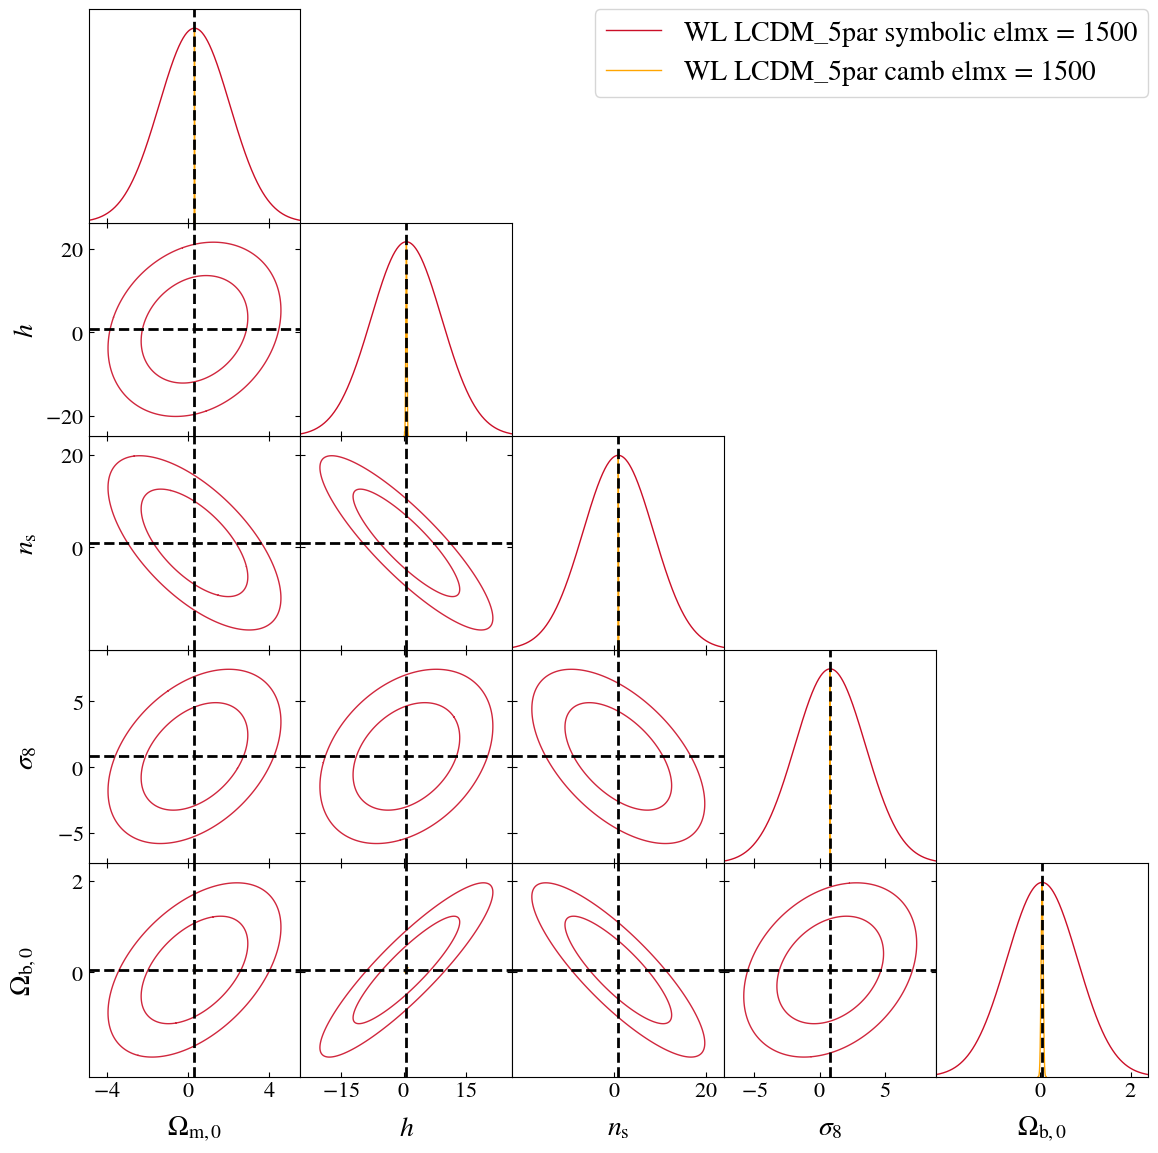

In [25]:
chooseind = [0,1]
plot_options = {'fishers_list': [Fishes_all[ii] for ii in chooseind], 
                'colors': [colorlist[ii] for ii in chooseind],
                'fish_labels': [Fishes_all[ii].name for ii in chooseind],
                'plot_pars': {'Omegab', 'sigma8', 'h', 'ns', 'Omegam'},
                'axis_custom_factors': {'all':3},  ## Axis limits cover 3-sigma bounds of first Fisher matrix
                'plot_method': 'Gaussian',
                'file_format': '.pdf',   ##file format for all the plots
                'outpath' : './plots/',  ## directory where to store the files, if non-existent, it will be created
                'outroot':'Euclid-LCDM5p-Symb_vs_CAMB-Nopri'  ## file name root for all the plots, extra names can be added individually
                } 
fish_plotter = fpp.fisher_plotting(**plot_options)
fish_plotter.plot_fisher(filled=[False, False, False, False])